# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The Google Play Store is one of the world's largest digital marketplaces, hosting millions of applications across diverse categories and serving billions of Android users. Understanding the characteristics of successful applications can provide valuable insights for developers and businesses seeking to improve user engagement and market performance. This dataset contains information on Google Play Store applications, including attributes such as category, rating, size, number of installs, reviews, price, and content rating. Through Exploratory Data Analysis (EDA), this project aims to uncover patterns, trends, and relationships among these features to better understand the factors that influence an app's popularity and user satisfaction.

CREDIT: L. Gupta, "Google Play Store Apps," Feb 2019. Available: https://www.kaggle.com/lava18/google-play-store-apps

# OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<li>To analyze the distribution of applications across different categories on the Google Play Store.
<li>To identify trends and patterns in app ratings, reviews, installs, and pricing.
<li>To examine the relationship between app characteristics and their popularity among users.
<li>To compare the performance of free and paid applications across various metrics.
<li>To uncover actionable insights that can help developers make informed decisions when designing and marketing Android applications.

<div>

# 1. Getting Ready With Dataset

In [115]:
import numpy as np 
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so



In [116]:

data = pl.read_csv(
    "/home/kartika/Datasets/googleplaystore.csv", 
    schema_overrides={
        "Reviews": pl.String,
        "Price": pl.String,
        "Installs": pl.String
    }
)
data = data.to_pandas()

data["Price"] = data["Price"].str.replace("$", "", regex=False).str.strip()
data["Price"] = pd.to_numeric(data["Price"], errors="coerce")


data["Reviews"] = pd.to_numeric(data["Reviews"], errors="coerce")
data.drop(index = [10472, 10474], inplace = True)

data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000,Free,0.0,Everyone,Art & Design,01/07/18,1.0.0,4.0.3 and up,None
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000,Free,0.0,Everyone,Art & Design,Pretend Play,01/15/18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000,Free,0.0,Everyone,Art & Design,08/01/18,1.2.4,4.0.3 and up,None
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000,Free,0.0,Teen,Art & Design,06/08/18,Varies with device,4.2 and up,None
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000,Free,0.0,Everyone,Art & Design,Creativity,06/20/18,1.1,4.4 and up


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Issue Identified: A column-shift anomaly was detected at row index 10474 (Life Made WI-Fi Touchscreen Photo Frame) due to a missing Category field. This shifted non-numeric strings into numerical columns (e.g., '3.0M' in Reviews, 'Everyone' in Price), causing schema parse failures.

Action Taken:

Overrode initial import schemas to ingest numeric target columns as raw strings.

Stripped currency formatting ($) and applied soft numeric coercion (pd.to_numeric(..., errors='coerce')) to turn misaligned strings into NaN values without interrupting pipeline execution.

Dropped the corrupted row to ensure dataset integrity across numeric analyses.

In [117]:
data.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,
10836,Sya9a Maroc - FR,FAMILY,4.5,38.0,53M,5000,Free,0.0,Everyone,Education,07/25/17,1.48,4.1 and up,None
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4.0,3.6M,100,Free,0.0,Everyone,Education,07/06/18,1,4.1 and up,None
10838,Parkinson Exercices FR,MEDICAL,NaN,3.0,9.5M,1000,Free,0.0,Everyone,Medical,01/20/17,1,2.2 and up,None
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114.0,Varies with device,1000,Free,0.0,Mature 17+,Books & Reference,01/19/15,Varies with device,Varies with device,None
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307.0,19M,10000000,Free,0.0,Everyone,Lifestyle,07/25/18,Varies with device,Varies with device,None


In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10839 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10839 non-null  object 
 1   Category        10839 non-null  object 
 2   Rating          9365 non-null   float64
 3   Reviews         10839 non-null  float64
 4   Size            10839 non-null  object 
 5   Installs        10839 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10839 non-null  float64
 8   Content Rating  10839 non-null  object 
 9   Genres          10839 non-null  object 
 10  Last Updated    10839 non-null  object 
 11  Current Ver     10838 non-null  object 
 12  Android Ver     10839 non-null  object 
 13                  499 non-null    object 
dtypes: float64(3), object(11)
memory usage: 1.2+ MB


In [119]:
data.isnull().sum()

App                   0
Category              0
Rating             1474
Reviews               0
Size                  0
Installs              0
Type                  0
Price                 0
Content Rating        0
Genres                0
Last Updated          0
Current Ver           1
Android Ver           0
                  10340
dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There are some columns with missing values, and some with inconsistent and non-unifrom values, which are handled in following ways. 

<div>

In [120]:
data['Rating'] = data['Rating'].fillna(data['Rating'].median())

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Since, 13.6% of the rows are null, instead of just filling with 0, filled it with median value to preserve distribution of data.

<div>

In [121]:
null_value = data.loc[data['Reviews'].isnull()]
null_value

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,


In [122]:
data['Reviews'] = data['Reviews'].fillna(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Since, only single value is missing, filled it with 0.

<di>

In [123]:
data.loc[data['Size'] == 'Varies with device']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639.0,Varies with device,5000000,Free,0.0,Everyone,Art & Design,07/14/18,Varies with device,2.3.3 and up,None
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221.0,Varies with device,10000000,Free,0.0,Everyone,Art & Design,07/30/18,Varies with device,Varies with device,None
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057.0,Varies with device,1000000,Free,0.0,Everyone,Auto & Vehicles,07/30/18,Varies with device,Varies with device,None
67,Ulysse Speedometer,AUTO_AND_VEHICLES,4.3,40211.0,Varies with device,5000000,Free,0.0,Everyone,Auto & Vehicles,07/30/18,Varies with device,Varies with device,None
68,REPUVE,AUTO_AND_VEHICLES,3.9,356.0,Varies with device,100000,Free,0.0,Everyone,Auto & Vehicles,05/25/18,Varies with device,Varies with device,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,My Earthquake Alerts - US & Worldwide Earthquakes,WEATHER,4.4,3471.0,Varies with device,100000,Free,0.0,Everyone,Weather,07/24/18,Varies with device,Varies with device,None
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8.0,Varies with device,1000,Free,0.0,Everyone,Maps & Navigation,09/27/17,Varies with device,4.4 and up,None
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622.0,Varies with device,100000,Free,0.0,Mature 17+,Social,05/23/18,Varies with device,Varies with device,None
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486.0,Varies with device,5000000,Free,0.0,Mature 17+,Social,03/23/18,Varies with device,Varies with device,None


In [124]:
def parse_size(val):
    if pd.isna(val) or val == 'Varies with device':
        return np.nan
    
    val = str(val).strip().upper()
    
    if 'M' in val:
        return float(val.replace('M', ''))
    
    elif 'K' in val:
        return float(val.replace('K', '')) / 1024
   
    elif 'G' in val:
        return float(val.replace('G', '')) * 1024

    elif '1,000+' in val:
        return 1
    


data['Size'] = data['Size'].apply(parse_size)

In [125]:
data['Size'] = data.groupby('Category')['Size'].transform(lambda x: x.fillna(x.median()))

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Replaced 'Varies with device', non standard record with np.nan. One record with '1,000+' is replaced by 1 MB. 
<br>
Standardised unit multipliers (M for Megabytes, k for Kilobytes), and converted to a unified numeric unit like MB.
<br>
App sizes usually correlate strongly with their Category (e.g., Games are usually much larger than Tools). Imputed by category median.

<div>

In [126]:

data['Installs'] = (
    data['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)


data['Installs'] = pd.to_numeric(data['Installs'], errors='coerce')


data['Installs'] = data['Installs'].fillna(0).astype(int)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Stripped non-numeric formatting symbols—specifically commas (,) and plus signs (+)—to retrieve raw numeric strings (e.g., '100000+ '10000+).
<br> Converted the column data type from object (string) to int64 to enable quantitative analysis and aggregation.

<div>

In [127]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10839 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10839 non-null  object 
 1   Category        10839 non-null  object 
 2   Rating          10839 non-null  float64
 3   Reviews         10839 non-null  float64
 4   Size            10839 non-null  float64
 5   Installs        10839 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10839 non-null  float64
 8   Content Rating  10839 non-null  object 
 9   Genres          10839 non-null  object 
 10  Last Updated    10839 non-null  object 
 11  Current Ver     10838 non-null  object 
 12  Android Ver     10839 non-null  object 
 13                  499 non-null    object 
dtypes: float64(4), int64(1), object(9)
memory usage: 1.2+ MB


In [128]:
data.drop(columns = ['Last Updated', 'Current Ver', 'Android Ver'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped least important fields.

<div>

<div>

# 1. Univariate Analysis

## 2.1 Core Application Identifiers

In [129]:
duplicates = data.loc[data['App'] == 'ROBLOX']
duplicates

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,
1653,ROBLOX,GAME,4.5,4447388.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
1701,ROBLOX,GAME,4.5,4447346.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
1748,ROBLOX,GAME,4.5,4448791.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
1841,ROBLOX,GAME,4.5,4449882.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
1870,ROBLOX,GAME,4.5,4449910.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
2016,ROBLOX,FAMILY,4.5,4449910.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
2088,ROBLOX,FAMILY,4.5,4450855.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
2206,ROBLOX,FAMILY,4.5,4450890.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up
4527,ROBLOX,FAMILY,4.5,4443407.0,67.0,100000000,Free,0.0,Everyone 10+,Adventure,4.1 and up


In [130]:

data = data.sort_values('Reviews')

data = data.drop_duplicates(subset='App', keep='last')

In [131]:
data['App'].value_counts()

App
EG Groups                                   1
E2CR CL                                     1
cronometra-br                               1
Miller's Bar B-Q                            1
BAR-B-Q Recipes                             1
                                           ..
Clash of Clans                              1
Messenger – Text and Video Chat for Free    1
Instagram                                   1
WhatsApp Messenger                          1
Facebook                                    1
Name: count, Length: 9658, dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Many apps appear multiple times.
The data might be scraped at different times, leading to change in reivews, install count for the same app. Some apps were assigned multiple categories.<br>
So, we kept the record with the largest number of reviews, that is the latest version of the app.


<div>

In [132]:
data['Category'].value_counts()

Category
FAMILY                 1877
GAME                    946
TOOLS                   829
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           314
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  170
VIDEO_PLAYERS           164
MAPS_AND_NAVIGATION     131
FOOD_AND_DRINK          112
EDUCATION               105
ENTERTAINMENT            86
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           73
EVENTS                   64
ART_AND_DESIGN           61
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

In [133]:
len(data['Category'].value_counts())

33

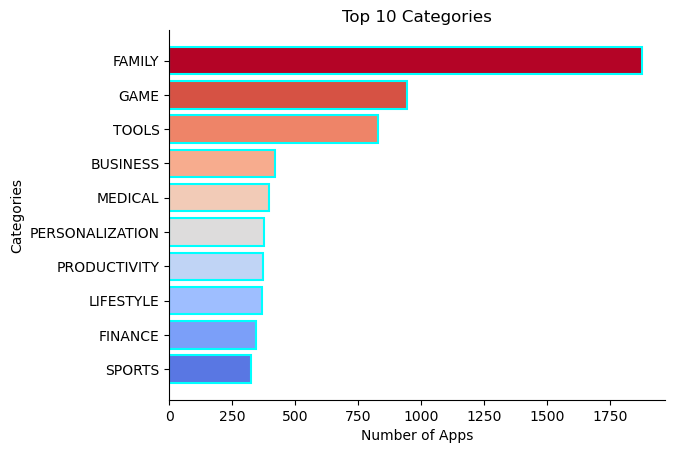

In [134]:
plt.barh(
    y = data['Category'].value_counts().head(10).index,
    width = data['Category'].value_counts().head(10).values,
    color = plt.cm.coolwarm(np.linspace(1, 0.10, 10)),
    linewidth = 1.5,
    edgecolor = 'cyan' 
)



plt.title('Top 10 Categories')
plt.ylabel('Categories')
plt.xlabel('Number of Apps')
plt.gca().invert_yaxis()
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The dataset features 33 different categories of app, showing wide range of categories of app on google playstore. The plot shows the top ten categories based on number of apps.

<div>

In [135]:
data['Genres'].value_counts()

Genres
Tools                      829
Entertainment              592
Education                  580
Business                   420
Medical                    395
Personalization            376
Productivity               374
Lifestyle                  370
Finance                    345
Sports                     335
Communication              315
Action                     311
Health & Fitness           290
Photography                281
News & Magazines           254
Social                     239
Books & Reference          225
Casual                     225
Travel & Local             219
Simulation                 206
Shopping                   202
Arcade                     199
Dating                     170
Video Players & Editors    165
Puzzle                     142
Maps & Navigation          131
Role Playing               115
Food & Drink               112
Racing                     108
Educational                102
Strategy                    99
Auto & Vehicles             85
L

In [136]:
len(data['Genres'].value_counts())

48

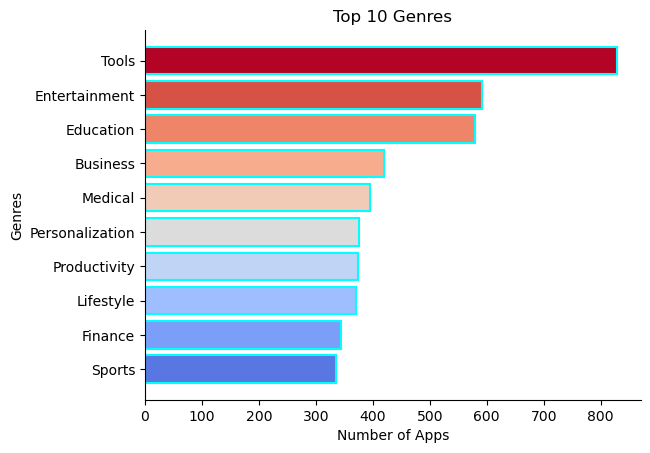

In [137]:
plt.barh(
    y = data['Genres'].value_counts().head(10).index,
    width = data['Genres'].value_counts().head(10).values,
    color = plt.cm.coolwarm(np.linspace(1, 0.10, 10)),
    linewidth = 1.5,
    edgecolor = 'cyan' 
)



plt.title('Top 10 Genres')
plt.ylabel('Genres')
plt.xlabel('Number of Apps')
plt.gca().invert_yaxis()
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The dataset features 48 different genres of app, showing wide range of genres of app on google playstore. The plot shows the top ten genres based on number of apps.

<div>

In [138]:

top_categories = data['Category'].value_counts().nlargest(5).index


df = data[data['Category'].isin(top_categories)]


top_genres = (df.groupby('Category')['Genres']
                .value_counts()
                .groupby(level=0)
                .head(5)
                .reset_index(name='Count'))

top_genres

,Category,Genres,Count
0,BUSINESS,Business,420
1,FAMILY,Entertainment,506
2,FAMILY,Education,475
3,FAMILY,Casual,202
4,FAMILY,Simulation,197
5,FAMILY,Puzzle,118
6,GAME,Action,300
7,GAME,Arcade,184
8,GAME,Racing,91
9,GAME,Adventure,73


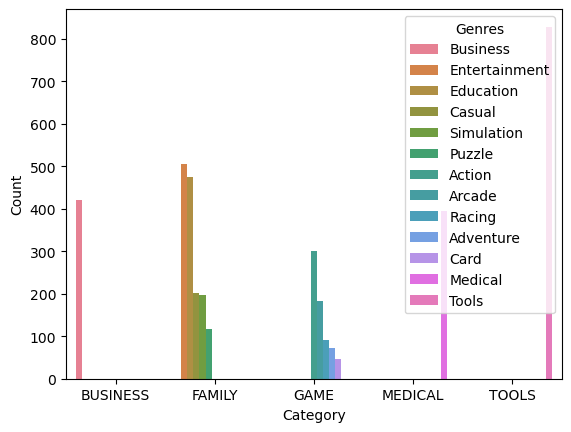

<Figure size 1600x600 with 0 Axes>

In [139]:
sns.barplot(
    data = top_genres,
    x = 'Category',
    y = 'Count',
    hue = 'Genres',

)

plt.figure(figsize = (16,6))
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">These are the top 3 genres from top 5 categories based on the number of apps.

<div>

## 2.2 Metrices and Performance

In [140]:
data['Rating'].describe()

count    9658.000000
mean        4.192545
std         0.496015
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [141]:
data['Rating'].skew()

np.float64(-1.9849779067861302)

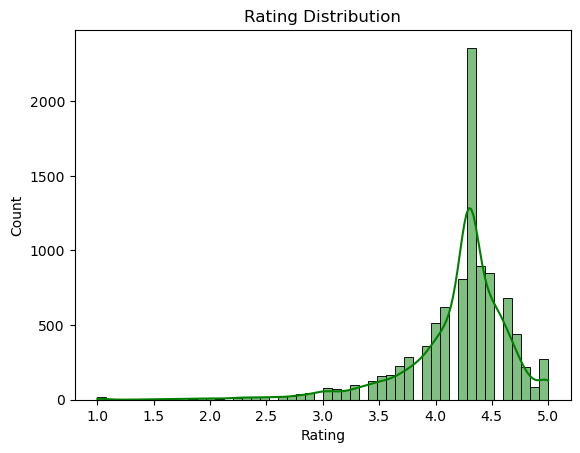

In [142]:
sns.histplot(
    data = data['Rating'],
    bins = 50,
    color = 'green',
    kde = True
)

plt.title('Rating Distribution')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The rating distribution is negatively skewed, indicating most of the apps have high rating, concentrated around an average rating of 4, while few apps have very low rating. These rating acts as an outliers pulling the distribution tails towards left.

<div>

In [143]:
data['Reviews'].describe()

count    9.658000e+03
mean     2.168266e+05
std      1.831524e+06
min      0.000000e+00
25%      2.500000e+01
50%      9.695000e+02
75%      2.945775e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [144]:
data['Reviews'].skew()

np.float64(26.56840442737942)

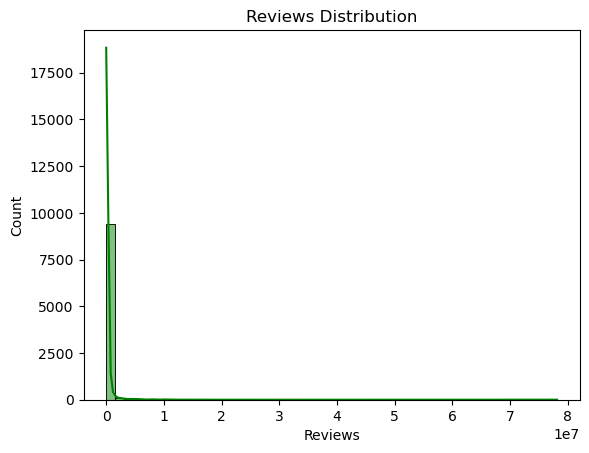

In [145]:
sns.histplot(
    data = data['Reviews'],
    bins = 50,
    color = 'green',
    kde = True
)

plt.title('Reviews Distribution')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The reviews distribution is extremely positively skewed. Most of the apps have low to medium number of reviews, while few apps have astronomical number of reviews. This apps must of older than other apps, generally older apps seems to have very high number of reviews.

<div>

In [146]:
data['Installs'].describe()

count    9.658000e+03
mean     7.798978e+06
std      5.377245e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [147]:
data['Installs'].skew()

np.float64(15.026624208764478)

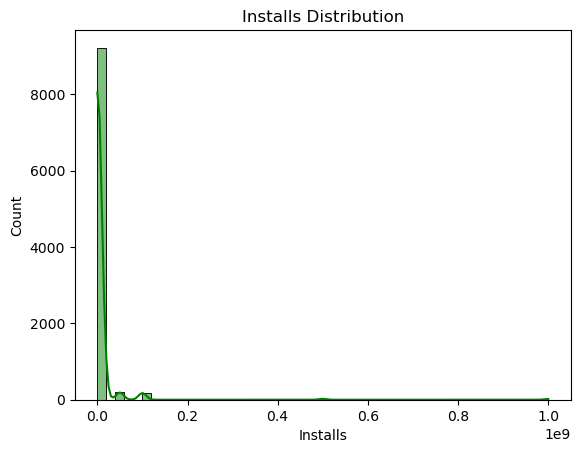

In [148]:
sns.histplot(
    data = data['Installs'],
    bins = 50,
    color = 'green',
    kde = True
)

plt.title('Installs Distribution')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The installs data is also extremely positively skewed, most of the apps have low to medium installations, while few have very high number of installations.

<div>

<div>

## 2.3 Commercial & Monetization

In [149]:
data['Type'] = data['Type'].replace({'NaN' : 'Free'})

In [150]:
data['Type'].value_counts()

Type
Free    8904
Paid     754
Name: count, dtype: int64

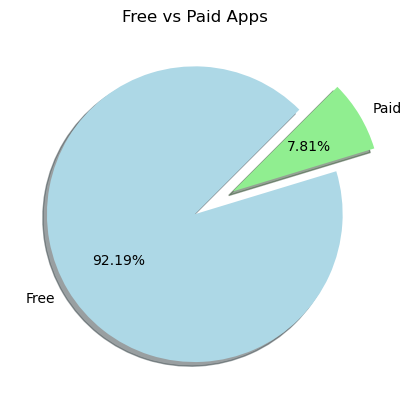

In [151]:
plt.pie(
    data['Type'].value_counts().values,
    labels = data['Type'].value_counts().index,
    autopct= '%1.2f%%',
    colors = ['lightblue', 'lightgreen'],
    explode = [0, 0.3],
    shadow = True,
    startangle = 45
)


plt.title('Free vs Paid Apps')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">92% of the apps are free, while nearly 8% of the apps are paid.

<div>

In [152]:
paid_apps = data.loc[data['Type'] == 'Paid']

paid_apps['Price'].describe()

count    754.000000
mean      14.055902
std       58.821000
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64

In [153]:
paid_apps['Price'].skew()

np.float64(6.139036727401034)

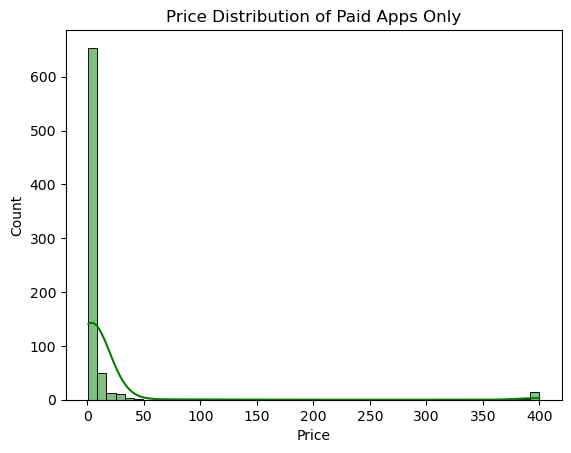

In [154]:
sns.histplot(
    data = paid_apps['Price'],
    bins = 50,
    color = 'green',
    kde = True
)

plt.title('Price Distribution of Paid Apps Only')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The price distribution of paid apps is heavily skewed. 75% of the free apps have pricing less than 4.99%, while rest of the apps have pricing greater than 5%.

In [155]:
paid_apps.loc[paid_apps['Price'].idxmax()]

App               I'm Rich - Trump Edition
Category                         LIFESTYLE
Rating                                 3.6
Reviews                              275.0
Size                                   7.3
Installs                             10000
Type                                  Paid
Price                                400.0
Content Rating                    Everyone
Genres                           Lifestyle
                                      None
Name: 4367, dtype: object

In [156]:
paid_apps.loc[paid_apps['Price'] > 300]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,
9934,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,4.3,0.0,40.000000,0,Paid,399.99,Everyone,Lifestyle,None
9917,Eu Sou Rico,FINANCE,4.3,0.0,1.400000,0,Paid,394.99,Everyone,Finance,None
4197,most expensive app (H),FAMILY,4.3,6.0,1.500000,100,Paid,399.99,Everyone,Entertainment,None
5373,I AM RICH PRO PLUS,FINANCE,4.0,36.0,41.000000,1000,Paid,399.99,Everyone,Finance,None
5357,I am extremely Rich,LIFESTYLE,2.9,41.0,2.900000,1000,Paid,379.99,Everyone,Lifestyle,None
5358,I am Rich!,FINANCE,3.8,93.0,22.000000,1000,Paid,399.99,Everyone,Finance,None
5364,I am rich (Most expensive app),FINANCE,4.1,129.0,2.700000,1000,Paid,399.99,Teen,Finance,None
5369,I am Rich,FINANCE,4.3,180.0,3.800000,5000,Paid,399.99,Everyone,Finance,None
5362,I Am Rich Pro,FAMILY,4.4,201.0,2.700000,5000,Paid,399.99,Everyone,Entertainment,None
5366,I Am Rich,FAMILY,3.6,217.0,4.900000,10000,Paid,389.99,Everyone,Entertainment,None


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">These are the apps with highest price, categorized as Lifestype and Finance. Intrestingly, they have decent number of installs.

<div>

<div>

## 2.4 Audience & Meta Data

In [158]:
data['Content Rating'].value_counts()

Content Rating
Everyone           7902
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

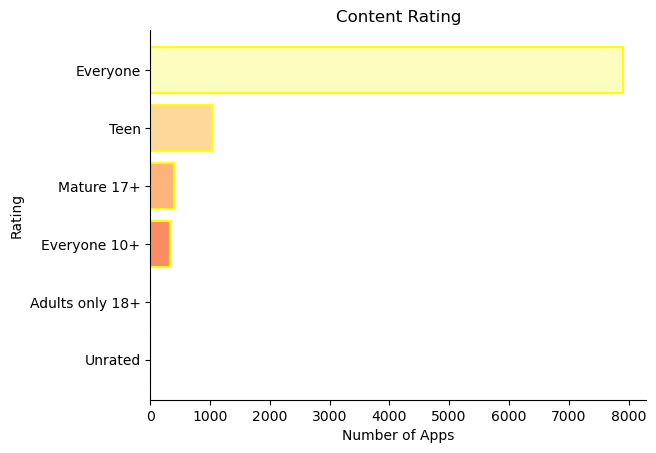

In [161]:
plt.barh(
    y = data['Content Rating'].value_counts().index,
    width = data['Content Rating'].value_counts().values,
    color = plt.cm.magma(np.linspace(1, 0.6, 6)),
    linewidth = 1.5,
    edgecolor = 'yellow'
)

plt.title('Content Rating')
plt.ylabel('Rating')
plt.xlabel('Number of Apps')
sns.despine()
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the apps are rated for everyone. Very few are for teens and mature audience.

<div>

In [162]:
data['Size'].describe()

count    9658.000000
mean       19.527689
std        20.756988
min         0.008301
25%         5.000000
50%        12.000000
75%        26.000000
max       100.000000
Name: Size, dtype: float64

In [164]:
bins = [0, 10, 30, 50, 80, 100]
labels = ['0-10MB', '10-30MB', '30-50MB', '50-80MB', '80-100MB']

data['size_category'] = pd.cut(data['Size'], bins = bins , labels = labels)

data['size_category'].value_counts()

size_category
0-10MB      4596
10-30MB     3077
30-50MB     1109
50-80MB      604
80-100MB     272
Name: count, dtype: int64

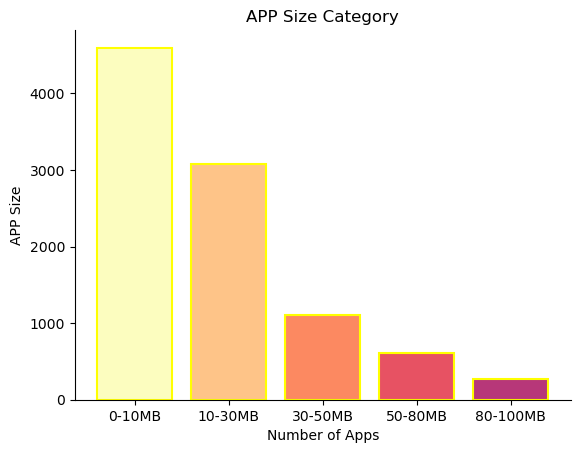

In [170]:
plt.bar(
    x = data['size_category'].value_counts().index,
    height = data['size_category'].value_counts().values,
    color = plt.cm.magma(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'yellow'
)

plt.title('APP Size Category')
plt.ylabel('APP Size')
plt.xlabel('Number of Apps')
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the app's size is below 10MB. Moderate number of apps with size >10MB are also represented in the dataset.

<div>

<iv>

# 3. 